In [ ]:
import subprocess

path_to_refimg = '../part2/data/plondres_template'
path_images_dir = '../part2/data/plondres_sequence'
path_output_dir = 'data/plondres_output'

group_path = '../part2'

cmd = ["python", "main2.py", path_to_refimg, path_images_dir, path_output_dir]

print(f"\nRunning command in {group_path}...")
try:
    result = subprocess.run(
        cmd,
        cwd=group_path,
        capture_output=True,
        text=True,
        check=False
    )
    stdout = result.stdout.strip()
    stderr = result.stderr.strip()

    # Print stdout to console
    print(stdout)
    if stderr:
        print(f"[stderr]\n{stderr}")

except Exception as e:
    print(f"Error running {group_path}: {e}")

print(f'Finished {group_path}')




Running command in ....
frame_0000.jpg
frame_0000.mat
frame_0001.jpg
frame_0001.mat
frame_0002.jpg
frame_0002.mat
frame_0003.jpg
frame_0003.mat
frame_0004.jpg
frame_0004.mat
frame_0005.jpg
frame_0005.mat
frame_0006.jpg
frame_0006.mat
frame_0007.jpg
frame_0007.mat
frame_0008.jpg
frame_0008.mat
frame_0009.jpg
frame_0009.mat
frame_0010.jpg
frame_0010.mat
frame_0011.jpg
frame_0011.mat
Finished .


# View merged point cloud

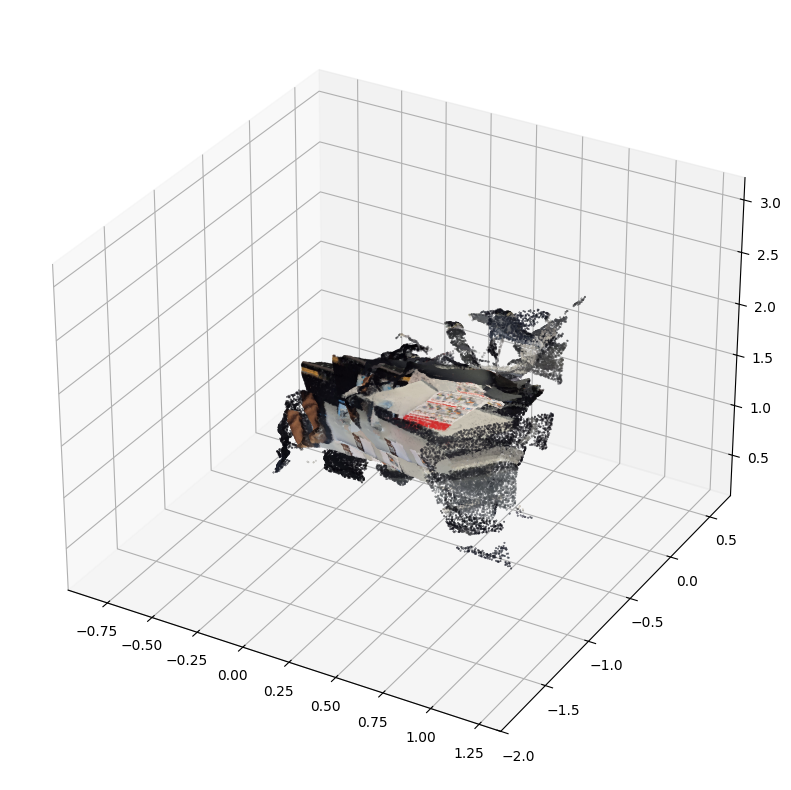

In [32]:
import scipy.io as sio
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

max_points = 50000

def get_pointcloud(dmpath):
    cam = sio.loadmat(dmpath)
    dm = cam['depth']
    K = cam['K']
    M, N = dm.shape
    u, v = np.meshgrid(np.arange(N), np.arange(M))
    pixels = np.stack((u, v, np.ones_like(u)), axis=-1)
    K_inv = np.linalg.inv(K)
    rays = pixels @ K_inv.T
    pc = rays * dm[..., np.newaxis]
    return pc

def pointcloud_with_color(pc, rgb):
    H, W, _ = pc.shape
    points = pc.reshape(-1, 3)
    colors = rgb.reshape(-1, 3) / 255.0
    valid = np.linalg.norm(points, axis=1) > 0
    points = points[valid]
    colors = colors[valid]
    # random subsampling
    if points.shape[0] > max_points:
        idx = np.random.choice(points.shape[0], max_points, replace=False)
        points = points[idx]
        colors = colors[idx]
    return points, colors

#load template data
tim = cv2.cvtColor(cv2.imread(os.path.join(path_to_refimg,'templatergb.jpg')),cv2.COLOR_BGR2RGB)
tpc = get_pointcloud(os.path.join(path_to_refimg,'templatedepth.mat'))
ref_pts, ref_colors = pointcloud_with_color(tpc, tim)

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(ref_pts[:,0], ref_pts[:,1], ref_pts[:,2], s=0.5, c=ref_colors, marker='.')

for fname in sorted(os.listdir(path_images_dir)):
    if fname.endswith('.jpg') or fname.endswith('.png'):
        im = cv2.cvtColor(cv2.imread(os.path.join(path_images_dir, fname)), cv2.COLOR_BGR2RGB)
        pc = get_pointcloud(os.path.join(path_images_dir, os.path.splitext(fname)[0] + ".mat"))
        data = sio.loadmat(os.path.join(group_path, path_output_dir, 'transform_' + os.path.splitext(fname)[0].split('_')[1] + '.mat'))
        R, T = data['R'], data['T'].reshape(3)
        pts, colors = pointcloud_with_color(pc, im)
        pts_trans = (R @ pts.T).T + T
        
        ax.scatter(pts_trans[:,0], pts_trans[:,1], pts_trans[:,2], s=0.5, c=colors, marker='.')

plt.show()